## Sagnac Frequency - Backscatter Correction - RZ FSR

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np

from pandas import DataFrame, read_pickle, date_range, concat, read_csv, DatetimeIndex
from obspy import UTCDateTime, read, Trace, Stream, read_inventory

import sys
sys.path.append("../")

from functions.read_sds import __read_sds
from functions.reduce import __reduce
from functions.smoothing import __smooth


In [2]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

## Configurations

In [3]:
config = {}

config['ring'] = "Z"

config['delta'] = 60

config['seed'] = f"BW.DROMY..FJ{config['ring']}"

config['path_to_sds'] = archive_path+"romy_archive/"

# with GPS reference and new settings
config['tbeg'] = UTCDateTime("2024-08-29 12:00")
config['tend'] = UTCDateTime("2024-09-05 00:00")
config['flim1'], config['flim2'] = 553.568, 553.580

# path to Sagnac data
# config['path_to_autodata'] = archive_path+f"romy_autodata/"
# config['path_to_out_data'] = data_path+"sagnac_frequency/data/"

config['path_to_data'] = data_path+"manuscripts/manuscript_romy_drifts/data/"

config['path_to_figs'] = data_path+"manuscripts/manuscript_romy_drifts/figures/"


### Load PROMY Data

In [4]:
ps = Stream()
ps += __read_sds(archive_path+"temp_archive/", "BW.PROMY.01.LKI", config['tbeg'], config['tend'])
ps += __read_sds(archive_path+"temp_archive/", "BW.PROMY.03.LKI", config['tbeg'], config['tend'])
ps += __read_sds(archive_path+"temp_archive/", "BW.PROMY.05.LKI", config['tbeg'], config['tend'])
ps += __read_sds(archive_path+"temp_archive/", "BW.PROMY.07.LKI", config['tbeg'], config['tend'])
ps += __read_sds(archive_path+"temp_archive/", "BW.PROMY.09.LKI", config['tbeg'], config['tend'])

ps3 = ps.merge();

ps

5 Trace(s) in Stream:
BW.PROMY.01.LKI | 2024-08-29T12:00:00.000000Z - 2024-09-05T00:00:00.000000Z | 1.0 Hz, 561601 samples
BW.PROMY.03.LKI | 2024-08-29T12:00:00.000000Z - 2024-09-05T00:00:00.000000Z | 1.0 Hz, 561601 samples
BW.PROMY.05.LKI | 2024-08-29T12:00:00.000000Z - 2024-09-05T00:00:00.000000Z | 1.0 Hz, 561601 samples
BW.PROMY.07.LKI | 2024-08-29T12:00:00.000000Z - 2024-09-05T00:00:00.000000Z | 1.0 Hz, 561601 samples
BW.PROMY.09.LKI | 2024-08-29T12:00:00.000000Z - 2024-09-05T00:00:00.000000Z | 1.0 Hz, 561601 samples

### Load Tilt Data

In [5]:
# path_to_tilt = archive_path+"romy_archive/"

# tromy0 = Stream()
# tromy0 += __read_sds(path_to_tilt, "BW.ROMYT..MAN", config['tbeg']-600, config['tend']+600)
# tromy0 += __read_sds(path_to_tilt, "BW.ROMYT..MAE", config['tbeg']-600, config['tend']+600)
# tromy0 += __read_sds(path_to_tilt, "BW.ROMYT..MAT", config['tbeg']-600, config['tend']+600)

# # tiltmeter configurations
# confTilt = __readYaml(root_path+"Documents/ROMY/tiltmeter/", "tiltmeter.conf")

# tromy0 = __conversion_to_tilt(tromy0, confTilt['TROMY'])

# tromy0 = tromy0.trim(config['tbeg'], config['tend']);

# tromy0 = tromy0.merge();

# tromy0.plot(equal_scale=False);

In [6]:
# NN = int(20*tromy0.select(channel="*N")[0].stats.sampling_rate)

# tromyN_smooth = __smooth(__reduce(tromy0.select(channel="*N")[0].data, 100), NN)
# tromyE_smooth = __smooth(__reduce(tromy0.select(channel="*E")[0].data, 100), NN)

### Load Water Level Data

In [7]:
# try:
#     pegel = __load_water_level(config['tbeg'], config['tend'], path_to_data=lamont_path+"Pegel/")

#     # remove error measurements with nan
#     pegel['pegel'] = np.where(pegel.pegel <= 0, np.nan, pegel.pegel)

#     pegel
# except Exception as e:
#     print(e)
#     print(" -> pegel not loaded")


### Load LXX Data

In [8]:
# # load log data
# lxx = __load_lxx(config['tbeg'], config['tend'], archive_path)

# # make intervals
# lxx_t1, lxx_t2 = __get_lxx_intervals(lxx.datetime)

### Load Beam Wander Data

In [9]:
df01 = read_pickle(config['path_to_data']+"ids01_fsr.pkl")

df03 = read_pickle(config['path_to_data']+"ids03_fsr.pkl")

df05 = read_pickle(config['path_to_data']+"ids05_fsr.pkl")

In [10]:
def __process(df0):

    # cut to time period
    df0 = df0[(df0.time_utc >= config['tbeg']) & (df0.time_utc <= config['tend'])]

    df0.loc[:, 'y_um_rel'] = __reduce(df0.y_um_rel, 3)
    df0.loc[:, 'x_um_rel'] = __reduce(df0.x_um_rel, 3)

    df0.reset_index(drop=True, inplace=True)
    return df0

df01 = __process(df01)
df03 = __process(df03)
df05 = __process(df05)

### Load Infrasound FFBI

In [11]:
ffbi = Stream()
ffbi += __read_sds(archive_path+"temp_archive/", "BW.FFBI.30.LDF", config['tbeg'], config['tend'])
ffbi += __read_sds(archive_path+"temp_archive/", "BW.FFBI.30.LDO", config['tbeg'], config['tend'])

In [12]:
ffbi_bdf_smooth1 = __smooth(ffbi.select(channel="*F")[0].data, int(60*ffbi.select(channel="*F")[0].stats.sampling_rate))
ffbi_bdf_smooth2 = __smooth(ffbi.select(channel="*F")[0].data, int(3600*ffbi.select(channel="*F")[0].stats.sampling_rate))

### Load FSR Data

In [13]:
fsr = read_pickle(config['path_to_data']+"romy_fsr_ex2.pkl")

fsr = fsr[(fsr.time_utc >= config['tbeg']) & (fsr.time_utc <= config['tend'])]

# fsr['disp_rel'] = __reduce(fsr.disp_rel, 10)

fsr['time_sec'] = [_t - config['tbeg'] for _t in fsr.time_utc]


In [14]:
fsr

,datetime,x_hz,y_dbm,time_sec,time_utc,x_mod,y_mod,disp,x_mod_avg,x_mod_std,disp_avg,disp_std,x_mod_rel,x_mod_avg_rel,disp_avg_rel
3586,2024-08-29 12:00:00.739891,1.072995e+08,-81.388664,0.739891,2024-08-29T12:00:00.739891Z,1.072995e+08,-81.388664,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3587,2024-08-29 12:00:01.743856,1.072995e+08,-77.397118,1.743856,2024-08-29T12:00:01.743856Z,1.072995e+08,-77.397118,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3588,2024-08-29 12:00:02.746753,1.072995e+08,-77.397118,2.746753,2024-08-29T12:00:02.746753Z,1.072995e+08,-77.397118,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3589,2024-08-29 12:00:03.752029,1.072995e+08,-77.043510,3.752029,2024-08-29T12:00:03.752029Z,1.072995e+08,-77.043510,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3590,2024-08-29 12:00:04.756119,1.072995e+08,-77.043510,4.756119,2024-08-29T12:00:04.756119Z,1.072995e+08,-77.043510,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562931,2024-09-04 23:59:55.552471,1.072993e+08,-79.383484,561595.552471,2024-09-04T23:59:55.552471Z,1.072993e+08,-79.383484,33.551007,1.072993e+08,0.700292,33.551007,2.190096e-07,-164.98,-164.830751,0.000052
562932,2024-09-04 23:59:56.556407,1.072993e+08,-77.595337,561596.556407,2024-09-04T23:59:56.556407Z,1.072993e+08,-77.595337,33.551007,1.072993e+08,0.700380,33.551007,2.190372e-07,-164.98,-164.831153,0.000052
562933,2024-09-04 23:59:57.560326,1.072993e+08,-77.595337,561597.560326,2024-09-04T23:59:57.560326Z,1.072993e+08,-77.595337,33.551007,1.072993e+08,0.700601,33.551007,2.191063e-07,-164.98,-164.831454,0.000052
562934,2024-09-04 23:59:58.564246,1.072993e+08,-77.951805,561598.564246,2024-09-04T23:59:58.564246Z,1.072993e+08,-77.951805,33.551007,1.072993e+08,0.700822,33.551007,2.191753e-07,-164.98,-164.831756,0.000052


## Get Tide Data

In [15]:
def __get_tides(tbeg, tend, component="N", typ="acc", df=3600):

    from pygtide import predict_series
    from numpy import arange, pi
    from obspy import UTCDateTime

    # ROMY
    lat = 48.162941
    lon = 11.275501
    height = 570

    startdate = str(UTCDateTime(tbeg).date)
    duration = (UTCDateTime(tend) - UTCDateTime(tbeg)) / 3600 # in hours
    sampling_rate = df # in seconds

    # creat time vector
    times = arange(0, duration+df/3600, df/3600)

    # prepare arguments
    args = (lat, lon, height, startdate, duration, sampling_rate)

    # specify station azimuth clockwise from north (=0)
    if component == "N":
        statazimut = 0
    elif component == "E":
        statazimut = 90

    if typ == "rad":
        # tides /= 9.81
        tides = predict_series(*args, statgravit=0, statazimut=statazimut, tidalcompo=1) # tilt

        # from mas to rad
        tides = tides * pi / 648000000

    elif typ == "acc":
        tides = predict_series(*args, statazimut=statazimut, tidalcompo=0) # horizontal acceleration

        # from nano to acc
        tides *= 1e-9

    elif typ == "str":
        tides = predict_series(*args, statazimut=statazimut, tidalcompo=5) # horizontal strain

        # from nano to str
        tides *= 1e-9

    return times, tides

In [16]:
t1, t2 = config['tbeg'].date, (config['tend']+86400).date

deltaT = 60

# predict tidal tilts
# timesN1, tideN1 = __get_tides(t1, t2, component="N", typ="rad", df=deltaT)
# timesE1, tideE1 = __get_tides(t1, t2, component="E", typ="rad", df=deltaT)

# predict horizontal strain
timesN3, tideN3 = __get_tides(t1, t2, component="N", typ="str", df=deltaT)
timesE3, tideE3 = __get_tides(t1, t2, component="E", typ="str", df=deltaT)

_tr = Trace()
_tr.data = tideE3
_tr.stats.delta = deltaT
_tr.stats.starttime = UTCDateTime(t1)

# _t1, _t2 = config['tbeg'].date, config['tend']
# _tr = _tr.trim(_t1, _t2)


_tr = Trace()
_tr.data = tideN3
_tr.stats.delta = deltaT
_tr.stats.starttime = UTCDateTime(t1)

# _t1, _t2 = config['tbeg'].date, config['tend']
# _tr = _tr.trim(_t1, _t2)

# tideNE = np.cos(np.deg2rad(30))*tideN3 + np.sin(np.deg2rad(30))*tideE3

/home/andbro/anaconda3/envs/obs2/lib/python3.10/site-packages/pygtide/core.py:348: UserWarning: Please consider updating the leap second database 'b'etddt.dat        '' (last value is from 2017-01-01 00:00:00).
  warn("Please consider updating the leap second database '%s' (last value is from %s)." % (fname, self.etddt_end))
/home/andbro/anaconda3/envs/obs2/lib/python3.10/site-packages/pygtide/core.py:352: UserWarning: Dates exceed permissible range for pole/LOD tide correction (interval 1962-01-01 00:00:00 to 2023-06-10 00:00:00). Consider update file 'b'etddt.dat        ''.
  warn("Dates exceed permissible range for pole/LOD tide correction (interval %s to %s). Consider update file '%s'." % (self.etpolut1_start, self.etpolut1_end, fname))


In [17]:
gc.collect()

0

## Join Data

In [18]:
fsr

,datetime,x_hz,y_dbm,time_sec,time_utc,x_mod,y_mod,disp,x_mod_avg,x_mod_std,disp_avg,disp_std,x_mod_rel,x_mod_avg_rel,disp_avg_rel
3586,2024-08-29 12:00:00.739891,1.072995e+08,-81.388664,0.739891,2024-08-29T12:00:00.739891Z,1.072995e+08,-81.388664,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3587,2024-08-29 12:00:01.743856,1.072995e+08,-77.397118,1.743856,2024-08-29T12:00:01.743856Z,1.072995e+08,-77.397118,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3588,2024-08-29 12:00:02.746753,1.072995e+08,-77.397118,2.746753,2024-08-29T12:00:02.746753Z,1.072995e+08,-77.397118,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3589,2024-08-29 12:00:03.752029,1.072995e+08,-77.043510,3.752029,2024-08-29T12:00:03.752029Z,1.072995e+08,-77.043510,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
3590,2024-08-29 12:00:04.756119,1.072995e+08,-77.043510,4.756119,2024-08-29T12:00:04.756119Z,1.072995e+08,-77.043510,33.550956,NaN,NaN,NaN,NaN,-0.73,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562931,2024-09-04 23:59:55.552471,1.072993e+08,-79.383484,561595.552471,2024-09-04T23:59:55.552471Z,1.072993e+08,-79.383484,33.551007,1.072993e+08,0.700292,33.551007,2.190096e-07,-164.98,-164.830751,0.000052
562932,2024-09-04 23:59:56.556407,1.072993e+08,-77.595337,561596.556407,2024-09-04T23:59:56.556407Z,1.072993e+08,-77.595337,33.551007,1.072993e+08,0.700380,33.551007,2.190372e-07,-164.98,-164.831153,0.000052
562933,2024-09-04 23:59:57.560326,1.072993e+08,-77.595337,561597.560326,2024-09-04T23:59:57.560326Z,1.072993e+08,-77.595337,33.551007,1.072993e+08,0.700601,33.551007,2.191063e-07,-164.98,-164.831454,0.000052
562934,2024-09-04 23:59:58.564246,1.072993e+08,-77.951805,561598.564246,2024-09-04T23:59:58.564246Z,1.072993e+08,-77.951805,33.551007,1.072993e+08,0.700822,33.551007,2.191753e-07,-164.98,-164.831756,0.000052


In [19]:
# reftime = fsr.time_utc.iloc[0]

# Tsec = int(abs(reftime - fsr.time_utc.iloc[fsr.shape[0]-1]))

# time2 = np.arange(0, Tsec, 1)

# fsr2 = DataFrame()

# fsr2['time_sec'] = time2

# fsr2['time_utc'] = [reftime + _t for _t in time2]
# fsr2['disp_avg'] = np.interp(time2, fsr.time_sec, fsr.disp_avg)

In [20]:
# set reference starttime
reftime = UTCDateTime("2024-08-29 18:00")

endtime = config['tend']

# create timeline in seconds
dt = 300
times = np.arange(0, abs(reftime-endtime), dt)

In [21]:
df = DataFrame()

# set timeline
df['time_sec'] = times

df['time_utc'] = [reftime + _t for _t in df['time_sec']]

df['time_utc_sec'] = [_t - reftime for _t in df.time_utc]

In [22]:
# add fsr displacement
df['disp'] = np.interp(df.time_utc_sec, fsr.time_utc - UTCDateTime(df.time_utc.iloc[0]), fsr.disp_avg)

# convert to micrometer
df['disp_um'] = df.disp*1e6

# add camera 01
df['x_01'] = np.interp(df.time_utc_sec, df01.time_utc - UTCDateTime(df.time_utc.iloc[0]), df01.x_um_rel)
df['y_01'] = np.interp(df.time_utc_sec, df01.time_utc - UTCDateTime(df.time_utc.iloc[0]), df01.y_um_rel)
df['a_01'] = np.sqrt(df.x_01**2 + df.y_01**2)

# add camera 03
df['x_03'] = np.interp(df.time_utc_sec, df03.time_utc - UTCDateTime(df.time_utc.iloc[0]), df03.x_um_rel)
df['y_03'] = np.interp(df.time_utc_sec, df03.time_utc - UTCDateTime(df.time_utc.iloc[0]), df03.y_um_rel)
df['a_03'] = np.sqrt(df.x_03**2 + df.y_03**2)

# add camera 05
df['x_05'] = np.interp(df.time_utc_sec, df05.time_utc - UTCDateTime(df.time_utc.iloc[0]), df05.x_um_rel)
df['y_05'] = np.interp(df.time_utc_sec, df05.time_utc - UTCDateTime(df.time_utc.iloc[0]), df05.y_um_rel)
df['a_05'] = np.sqrt(df.x_05**2 + df.y_05**2)

# add barometer
df['baro'] = np.interp(df.time_utc_sec, ffbi[1].times(reftime=df.time_utc.iloc[0]), ffbi[1].data)

# smooth barometer
# df['baro_sth'] = __smooth(df.baro, 60*30)

# add temperature data
df['temp_05'] = np.interp(df.time_utc_sec, ps[0].times(reftime=df.time_utc.iloc[0]), ps.select(location="05")[0].data)
df['temp_07'] = np.interp(df.time_utc_sec, ps[0].times(reftime=df.time_utc.iloc[0]), ps.select(location="07")[0].data)
df['temp_09'] = np.interp(df.time_utc_sec, ps[0].times(reftime=df.time_utc.iloc[0]), ps.select(location="09")[0].data)

# smoothing
# df['temp_05'] = __smooth(df.temp_05, 60*30)
# df['temp_07'] = __smooth(df.temp_07, 60*30)
# df['temp_09'] = __smooth(df.temp_09, 60*30)

# relative temperature
# df['temp_05_rel'] = df['temp_05'] - df['temp_05'].iloc[0]
# df['temp_07_rel'] = df['temp_07'] - df['temp_07'].iloc[0]
# df['temp_09_rel'] = df['temp_09'] - df['temp_09'].iloc[0]

# add cumulative temperature
temp = ps.select(location="05")[0].data + ps.select(location="07")[0].data + ps.select(location="09")[0].data
df['temp'] = np.interp(df.time_utc_sec, ps[0].times(reftime=df.time_utc.iloc[0]), temp)

# smooth temperature
# df['temp_sth'] = __smooth(df.temp, 60*30)

# add to frame
df['tideE'] = np.interp(df.time_utc_sec, _tr.times(reftime=reftime), _tr.data)
df['tideN'] = np.interp(df.time_utc_sec, _tr.times(reftime=reftime), _tr.data)

df = df.dropna()

In [23]:
# add relative data
for k in df.keys():
    if k not in ["time_utc", "time_utc_sec", "times_sec"]:
        df[k+"_sth"] = __smooth(df[k].values, 600)
for k in df.keys():
    if k not in ["time_utc", "time_utc_sec", "times_sec"]:
        df[k+"_rel"] = __reduce(df[k].values, 10)


## Create Stream

In [24]:
def __df_to_stream(df0, dt, t1):

    st0 = Stream()

    for k in df.keys():
        if "_sth" in k:
            continue
        if "_rel" in k:
            continue

        _tr = Trace()
        _tr.data = np.array(df[k].values)
        _tr.stats.delta = dt
        _tr.stats.starttime = UTCDateTime(t1)
        _tr.stats.station = k

        st0 += _tr

    return st0

In [48]:
stt = __df_to_stream(df, dt, reftime)

In [49]:
# apply highpass filter
stt = stt.detrend("linear")
stt = stt.detrend("simple")
stt = stt.taper(0.01, type="cosine")

fupper = 1/(1.5*86400)
# fupper = 1/(5*3600)

stt = stt.filter("highpass", freq=fupper, corners=2, zerophase=True)

print(stt.__str__(extended=True))

# stt.plot(equal_scale=False);

21 Trace(s) in Stream:
.time_sec..     | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.time_utc..     | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.time_utc_sec.. | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.disp..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.disp_um..      | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.x_01..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.y_01..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.a_01..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.x_03..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z | 300.0 s, 1800 samples
.y_03..         | 2024-08-29T18:00:00.000000Z - 2024-09-04T23:55:00.000000Z |

## Plotting

In [65]:
def __makeplot1():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec
    from scipy.signal import detrend
    from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
    from functions.compute_orthogonal_distance_regression import __compute_orthogonal_distance_regression

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    reftime = df.time_utc.iloc[0]

    Ncol, Nrow = 8, 3

    font = 12

    fig = plt.figure(figsize=(15, 10))

    gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.3, wspace=0.4)

    ax10 = fig.add_subplot(gs1[0, :6])
    ax11 = fig.add_subplot(gs1[0, 6:])
    ax20 = fig.add_subplot(gs1[1, :6])
    ax21 = fig.add_subplot(gs1[1, 6:])
    ax30 = fig.add_subplot(gs1[2, :6])
    ax31 = fig.add_subplot(gs1[2, 6:])

    axes0 = [ax10, ax20, ax30]
    axes1 = [ax11, ax21, ax31]

    # ___________________________________________

    ax10.plot(df.time_utc_sec*tscale, df.disp_um_rel,
              color="purple", label="$\Delta$P")
    ax10.plot(df.time_utc_sec*tscale, df.temp_sth_rel*30,
              color='k', label="$\Delta$T x 30 $\mu$m/°C")

    _fac = -3
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_01_rel,
    #           color="tab:blue", label=f"{_fac}x IDS01-X")
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_03_rel,
    #           color="tab:orange", label=f"{_fac}x IDS03-X")
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_05_rel,
    #           color="tab:red", label=f"{_fac}x IDS05-X")

#     ax11.scatter(df.temp_sth_rel, df.disp_um_rel, s=1, color="purple")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_01_rel, s=1, color="tab:blue")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_03_rel, s=1, color="tab:orange")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_05_rel, s=1, color="tab:red")

    _fac = 1
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_01_rel,
              color="tab:blue", label= "IDS01-A")
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_03_rel,
              color="tab:orange", label="IDS03-A")
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_05_rel,
              color="tab:red", label="IDS05-A")

    ax11.scatter(df.temp_sth_rel, df.disp_um_rel, s=1, color="purple")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_01_rel, s=1, color="tab:blue")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_03_rel, s=1, color="tab:orange")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_05_rel, s=1, color="tab:red")

    # ___________________________________________

    ax20.plot(df.time_utc_sec*tscale, stt.select(station="baro")[0].data,
              color='k', label="FFBI x 1 $\mu$m/hPa")
    ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_01")[0].data,
              color="tab:blue", label="-1x IDS01-Y")
    # ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_03")[0].data,
    #           color="tab:orange", label="-1x IDS03-Y")
    # ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_05")[0].data,
    #           color="tab:red", label="-1x IDS05-Y")
    _sfac = 4
    ax20.plot(df.time_utc_sec*tscale, stt.select(station="disp")[0].data*1e6*_sfac,
              color="purple", label=f"{_sfac}x $\Delta$P",
             )

    ax21.scatter(stt.select(station="baro")[0].data, stt.select(station="disp")[0].data*1e6,
                 s=1, color="purple", alpha=0.7)
    ax21.scatter(stt.select(station="baro")[0].data, stt.select(station="y_01")[0].data,
                 s=1, color="tab:blue", alpha=0.7)
#     ax21.scatter(stt.select(station="baro")[0].data, -stt.select(station="y_03")[0].data,
#                  s=1, color="tab:orange")
#     ax21.scatter(stt.select(station="baro")[0].data, -stt.select(station="y_05")[0].data,
#                  s=1, color="tab:red")

    out = __compute_orthogonal_distance_regression(stt.select(station="baro")[0].data,
                                                   stt.select(station="disp")[0].data*1e6,
                                                   intercept_zero=True,
                                                  )
    print(out)
    ax21.plot(stt.select(station="baro")[0].data,
              stt.select(station="baro")[0].data*out['slope'],
              color="purple", label=f"{round(out['slope'][0], 2)} xP"
             )

    out = __compute_orthogonal_distance_regression(stt.select(station="baro")[0].data,
                                                   stt.select(station="y_01")[0].data,
                                                   intercept_zero=True,
                                                  )
    print(out)
    ax21.plot(stt.select(station="baro")[0].data,
              stt.select(station="baro")[0].data*out['slope'],
              color="tab:blue", label=f"{round(out['slope'][0], 2)} xP"
             )


#     # ___________________________________________

    ax30.plot(df.time_utc_sec*tscale, stt.select(station="x_01")[0].data/33.5*1e3,
              color="tab:blue", label="IDS01-X / P", alpha=0.7)
    ax30.plot(df.time_utc_sec*tscale, stt.select(station="x_03")[0].data/33.5*1e3,
              color="tab:orange", label="IDS03-X / P", alpha=0.7)
    ax30.plot(df.time_utc_sec*tscale, stt.select(station="x_05")[0].data/33.5*1e3,
              color="tab:red", label="IDS05-X / P", alpha=0.7)

    # x_sum = stt.select(station="x_03")[0].data+stt.select(station="x_05")[0].data
    # ax30.plot(df.time_utc_sec*tscale, x_sum/33.5*1e3,
    #           color="k", ls="--", label="(IDS03-X + IDS05-X) / P")

    ax30.plot(df.time_utc_sec*tscale, df.tideE*1e9, color='k', label="Tidal Strain-E")

    # ax30.plot(df.time_utc_sec*tscale, stt.select(station="disp")[0].data*1e6*33.5,
    #           color="purple", label=f"$\Delta$P",
    #          )

    # ax31.scatter(df.tideE*1e9, detrend(df.x_01, type="linear")/33.5*1e3,
    #              s=1, color="tab:blue")
    # ax31.scatter(df.tideE*1e9, detrend(df.x_03, type="linear")/33.5*1e3,
    #              s=1, color="tab:orange")
    # ax31.scatter( f.tideE*1e9, detrend(df.x_05, type="linear")/33.5*1e3,
    #              s=1, color="tab:red")

    # ax31.scatter(df.tideE*1e9, x_sum/33.5*1e3,
    #              s=1, color="k")

    ax10.set_ylim(-5, 50)
    ax11.set_ylim(-5, 50)

    ax20.set_ylim(-2, 2)
    ax21.set_ylim(-2, 2)
    ax21.set_xlim(-2, 2)

    ax30.set_ylim(-30, 30)
    ax31.set_ylim(-30, 30)
    ax31.set_xlim(-30, 30)

    for ax in axes0:
        ax.xaxis.set_major_locator(MultipleLocator(24))
        ax.xaxis.set_minor_locator(MultipleLocator(6))

    for _k, (ll, ax) in enumerate(zip(['(a)','(b)','(c)','(d)','(e)','(f)'], axes0+axes1)):
        ax.text(0.008, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

    for ax in axes0:
        ax.set_xlim(0, (config['tend']-config['tbeg']-86400)*tscale)
        ax.set_xlabel(f"Time ({tunit})", fontsize=font)
    for ax in axes0+axes1:
        ax.grid(ls=":", alpha=0.5, zorder=0, which="both")

    ax20.text(0.05, 0.97, f"hp < {int(1/fupper/3600)}h", ha="left", va="top", transform=ax20.transAxes, fontsize=font-1)
    ax30.text(0.05, 0.97, f"hp < {int(1/fupper/3600)}h", ha="left", va="top", transform=ax30.transAxes, fontsize=font-1)

    ax10.legend(loc=9, ncol=3)
    ax20.legend(loc=8, ncol=5)
    ax21.legend(loc=8, ncol=5)
    ax30.legend(loc=8, ncol=5)

    ax10.set_ylabel(f"rel. Displacement ($\mu$m)", fontsize=font)
    ax20.set_ylabel(f"rel. Displacement ($\mu$m)", fontsize=font)
    ax30.set_ylabel(f"rel. Displacement (nm)", fontsize=font)

    ax11.set_xlabel(f"rel. Temperature (°C)", fontsize=font)
    ax21.set_xlabel(f"rel. Pressure (hPa)", fontsize=font)
    ax31.set_xlabel(f"Strain (nm)", fontsize=font)

    plt.show();
    return fig

# fig = __makeplot1()

# fig.savefig(config['path_to_figs']+f"FSR_RZ_{config['tbeg']}_{config['tend']}_gps_analysis_hp.png",
#             format="png", dpi=150, bbox_inches='tight')


{'slope': array([0.14260833])}
{'slope': array([-0.88028945])}


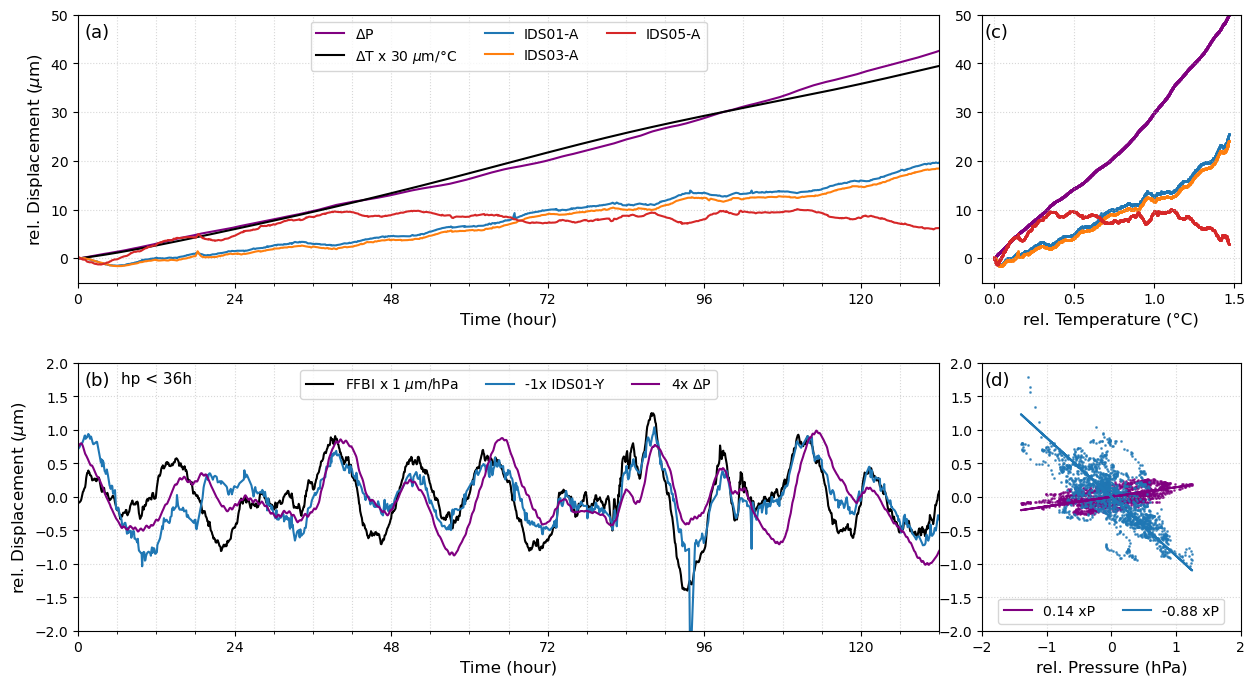

In [69]:
def __makeplot2():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec
    from scipy.signal import detrend
    from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
    from functions.compute_orthogonal_distance_regression import __compute_orthogonal_distance_regression

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    reftime = df.time_utc.iloc[0]

    Ncol, Nrow = 8, 2

    font = 12

    fig = plt.figure(figsize=(15, 8))

    gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.3, wspace=0.4)

    ax10 = fig.add_subplot(gs1[0, :6])
    ax11 = fig.add_subplot(gs1[0, 6:])
    ax20 = fig.add_subplot(gs1[1, :6])
    ax21 = fig.add_subplot(gs1[1, 6:])
    # ax30 = fig.add_subplot(gs1[2, :6])
    # ax31 = fig.add_subplot(gs1[2, 6:])

    axes0 = [ax10, ax20]
    axes1 = [ax11, ax21]

    # ___________________________________________

    ax10.plot(df.time_utc_sec*tscale, df.disp_um_rel,
              color="purple", label="$\Delta$P")
    ax10.plot(df.time_utc_sec*tscale, df.temp_sth_rel*30,
              color='k', label="$\Delta$T x 30 $\mu$m/°C")

    _fac = -3
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_01_rel,
    #           color="tab:blue", label=f"{_fac}x IDS01-X")
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_03_rel,
    #           color="tab:orange", label=f"{_fac}x IDS03-X")
    # ax10.plot(df.time_utc_sec*tscale, _fac*df.a_05_rel,
    #           color="tab:red", label=f"{_fac}x IDS05-X")

#     ax11.scatter(df.temp_sth_rel, df.disp_um_rel, s=1, color="purple")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_01_rel, s=1, color="tab:blue")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_03_rel, s=1, color="tab:orange")
#     ax11.scatter(df.temp_sth_rel, _fac*df.x_05_rel, s=1, color="tab:red")

    _fac = 1
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_01_rel,
              color="tab:blue", label= "IDS01-A")
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_03_rel,
              color="tab:orange", label="IDS03-A")
    ax10.plot(df.time_utc_sec*tscale, _fac*df.a_05_rel,
              color="tab:red", label="IDS05-A")

    ax11.scatter(df.temp_sth_rel, df.disp_um_rel, s=1, color="purple")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_01_rel, s=1, color="tab:blue")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_03_rel, s=1, color="tab:orange")
    ax11.scatter(df.temp_sth_rel, _fac*df.a_05_rel, s=1, color="tab:red")

    # ___________________________________________

    ax20.plot(df.time_utc_sec*tscale, stt.select(station="baro")[0].data,
              color='k', label="FFBI x 1 $\mu$m/hPa")
    ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_01")[0].data,
              color="tab:blue", label="-1x IDS01-Y")
    # ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_03")[0].data,
    #           color="tab:orange", label="-1x IDS03-Y")
    # ax20.plot(df.time_utc_sec*tscale, -stt.select(station="y_05")[0].data,
    #           color="tab:red", label="-1x IDS05-Y")
    _sfac = 4
    ax20.plot(df.time_utc_sec*tscale, stt.select(station="disp")[0].data*1e6*_sfac,
              color="purple", label=f"{_sfac}x $\Delta$P",
             )

    ax21.scatter(stt.select(station="baro")[0].data, stt.select(station="disp")[0].data*1e6,
                 s=1, color="purple", alpha=0.7)
    ax21.scatter(stt.select(station="baro")[0].data, stt.select(station="y_01")[0].data,
                 s=1, color="tab:blue", alpha=0.7)
#     ax21.scatter(stt.select(station="baro")[0].data, -stt.select(station="y_03")[0].data,
#                  s=1, color="tab:orange")
#     ax21.scatter(stt.select(station="baro")[0].data, -stt.select(station="y_05")[0].data,
#                  s=1, color="tab:red")

    out = __compute_orthogonal_distance_regression(stt.select(station="baro")[0].data,
                                                   stt.select(station="disp")[0].data*1e6,
                                                   intercept_zero=True,
                                                  )
    print(out)
    ax21.plot(stt.select(station="baro")[0].data,
              stt.select(station="baro")[0].data*out['slope'],
              color="purple", label=f"{round(out['slope'][0], 2)} xP"
             )

    out = __compute_orthogonal_distance_regression(stt.select(station="baro")[0].data,
                                                   stt.select(station="y_01")[0].data,
                                                   intercept_zero=True,
                                                  )
    print(out)
    ax21.plot(stt.select(station="baro")[0].data,
              stt.select(station="baro")[0].data*out['slope'],
              color="tab:blue", label=f"{round(out['slope'][0], 2)} xP"
             )

    ax10.set_ylim(-5, 50)
    ax11.set_ylim(-5, 50)

    ax20.set_ylim(-2, 2)
    ax21.set_ylim(-2, 2)
    ax21.set_xlim(-2, 2)

    for ax in axes0:
        ax.xaxis.set_major_locator(MultipleLocator(24))
        ax.xaxis.set_minor_locator(MultipleLocator(6))

    for _k, (ll, ax) in enumerate(zip(['(a)','(b)','(c)','(d)','(e)','(f)'], axes0+axes1)):
        ax.text(0.008, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

    for ax in axes0:
        ax.set_xlim(0, (config['tend']-config['tbeg']-86400)*tscale)
        ax.set_xlabel(f"Time ({tunit})", fontsize=font)
    for ax in axes0+axes1:
        ax.grid(ls=":", alpha=0.5, zorder=0, which="both")

    ax20.text(0.05, 0.97, f"hp < {int(1/fupper/3600)}h", ha="left", va="top", transform=ax20.transAxes, fontsize=font-1)

    ax10.legend(loc=9, ncol=3)
    ax20.legend(loc=9, ncol=5)
    ax21.legend(loc=8, ncol=5)

    ax10.set_ylabel(f"rel. Displacement ($\mu$m)", fontsize=font)
    ax20.set_ylabel(f"rel. Displacement ($\mu$m)", fontsize=font)

    ax11.set_xlabel(f"rel. Temperature (°C)", fontsize=font)
    ax21.set_xlabel(f"rel. Pressure (hPa)", fontsize=font)

    plt.show();
    return fig

fig = __makeplot2()

# fig.savefig(config['path_to_figs']+f"FSR_RZ_{config['tbeg']}_{config['tend']}_gps_analysis_hp.png",
#             format="png", dpi=150, bbox_inches='tight')


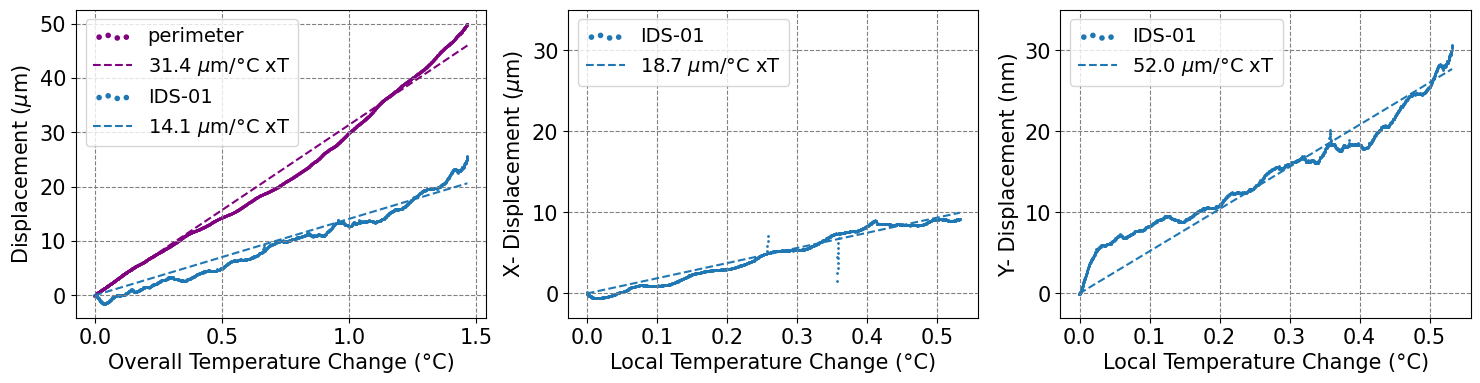

In [70]:
def __makeplot3():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec
    from scipy.signal import detrend
    from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
    from functions.compute_orthogonal_distance_regression import __compute_orthogonal_distance_regression

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    reftime = df.time_utc.iloc[0]

    Ncol, Nrow = 3, 1

    font = 15

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(18, 4))

    # ___________________________________________

    _fac = 1
    ax[0].scatter(df.temp_sth_rel, df.disp_um_rel, s=1, color="purple", label="perimeter")

    out = __compute_orthogonal_distance_regression(df.temp_sth_rel, df.disp_um_rel, intercept_zero=True)
    ax[0].plot(df.temp_sth_rel, df.temp_sth_rel*out['slope'], color="purple",
               label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT", ls="--"
              )

    ax[0].scatter(df.temp_sth_rel, _fac*df.a_01_rel, s=1, color="tab:blue", label="IDS-01")

    out = __compute_orthogonal_distance_regression(df.temp_sth_rel, df.a_01_rel, intercept_zero=True)
    ax[0].plot(df.temp_sth_rel, df.temp_sth_rel*out['slope'], color="tab:blue",
               label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT", ls="--"
              )

    # ax[0].scatter(df.temp_sth_rel, _fac*df.a_05_rel, s=1, color="tab:red", label="IDS-05")

    # out = __compute_orthogonal_distance_regression(df.temp_sth_rel, df.a_05_rel, intercept_zero=True)
    # ax[0].plot(df.temp_sth_rel, df.temp_sth_rel*out['slope'], color="tab:red",
    #            label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT"
    #           )

    # ___________________________________________

    ax[1].scatter(df.temp_07_sth_rel, _fac*df.x_01_rel, s=1, color="tab:blue", label="IDS-01")

    out = __compute_orthogonal_distance_regression(df.temp_07_sth_rel, df.x_01_rel, intercept_zero=True)
    ax[1].plot(df.temp_07_sth_rel, df.temp_07_sth_rel*out['slope'],
               color="tab:blue", label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT", ls="--"
              )

#     ax[1].scatter(df.temp_09_sth_rel, _fac*df.x_05_rel, s=1, color="tab:red", label="IDS-05")

#     out = __compute_orthogonal_distance_regression(df.temp_09_sth_rel, df.x_05_rel, intercept_zero=True)
#     ax[1].plot(df.temp_09_sth_rel, df.temp_09_sth_rel*out['slope'],
#                color="tab:red", label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT"
#               )

    # ___________________________________________

    ax[2].scatter(df.temp_07_sth_rel, _fac*df.y_01_rel, s=1, color="tab:blue", label="IDS-01")

    out = __compute_orthogonal_distance_regression(df.temp_07_sth_rel, df.y_01_rel, intercept_zero=True)
    ax[2].plot(df.temp_07_sth_rel, df.temp_07_sth_rel*out['slope'],
               color="tab:blue", label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT", ls="--"
              )

#     ax[2].scatter(df.temp_09_sth_rel, _fac*df.y_05_rel, s=1, color="tab:red", label="IDS-05")

#     out = __compute_orthogonal_distance_regression(df.temp_09_sth_rel, df.y_05_rel, intercept_zero=True)
#     ax[2].plot(df.temp_09_sth_rel, df.temp_09_sth_rel*out['slope'],
#                color="tab:red", label=f"{round(out['slope'][0], 1)} $\mu$m/°C xT"
#               )

    ax[0].legend(loc=2, ncol=1, markerscale=3, scatterpoints=4, fontsize=font-1)
    ax[1].legend(loc=2, ncol=1, markerscale=3, scatterpoints=4, fontsize=font-1)
    ax[2].legend(loc=2, ncol=1, markerscale=3, scatterpoints=4, fontsize=font-1)

    ax[0].set_ylabel(f"Displacement ($\mu$m)", fontsize=font)
    ax[1].set_ylabel(f"X- Displacement ($\mu$m)", fontsize=font)
    ax[2].set_ylabel(f"Y- Displacement (nm)", fontsize=font)

    ax[0].set_xlabel(f"Overall Temperature Change (°C)", fontsize=font)
    ax[1].set_xlabel(f"Local Temperature Change (°C)", fontsize=font)
    ax[2].set_xlabel(f"Local Temperature Change (°C)", fontsize=font)

    ax[1].set_ylim(-3, 35)
    ax[2].set_ylim(-3, 35)

    for a in ax:
        a.grid(which="both", ls="--", color="grey", zorder=0)
        a.tick_params(axis='both', labelsize=font)

    plt.show();
    return fig

fig = __makeplot3()

fig.savefig(config['path_to_figs']+f"FSR_RZ_{config['tbeg']}_{config['tend']}_gps_analysis_linear.png",
            format="png", dpi=150, bbox_inches='tight')

# fig.savefig("/home/andbro/Downloads/"+f"FSR_RZ_{config['tbeg']}_{config['tend']}_gps_analysis_linear.png",
#             format="png", dpi=150, bbox_inches='tight')


In [29]:
days = stt[0].times()[-1]/86400

In [30]:
14.1 / hours, 31.4 / days

NameError: name 'hours' is not defined

In [91]:
L = 11.2
lamda = 632.8e-9
omega_e = 2 * np.pi/ 86400

deltaf = L *np.sqrt(3) /3 /lamda *omega_e *np.sin(np.deg2rad(48.162941))

delta_L = 31.4e-6/days/3
deltaf_L = (L+delta_L) *np.sqrt(3) /3 /lamda *omega_e *np.sin(np.deg2rad(48.162941))

delta_phi = np.arctan(20e-6/6)
deltaf_phi = (L) *np.sqrt(3) /3 /lamda *omega_e *np.sin(np.deg2rad(48.162941)+delta_phi) # *np.cos(delta_phi)

print(f"{deltaf}")
print(f"{(deltaf_L - deltaf)*1e6} uHz")
print(f"{(deltaf_phi - deltaf)*1e3} mHz")


553.6552182680465
82.83065437808546 uHz
1.6522290974307907 mHz
